# DS605 Lab 6: Feature Extraction and Machine Learning with Image and Text Data


In [18]:
import os, re, time, glob, warnings
from collections import Counter

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

IMAGE_DIR = "data/images"   
TEXT_CSV  = "data/emails.csv"
OUT_DIR   = "outputs"
IMG_SIZE  = (128, 128)               
DARK_T, BRIGHT_T = 60, 200           
SEED = 42
TOKEN = r"(?u)\b\w+\b"                
LABEL_OVERRIDE = {}
os.makedirs(OUT_DIR, exist_ok=True)

---
# Part A: Image Feature Extraction and Classification
## A1. Load images, inspect dimensions/channels

In [19]:
EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
paths = sorted(p for p in glob.glob(os.path.join(IMAGE_DIR, "**", "*"), recursive=True) if p.lower().endswith(EXTS))
assert len(paths) > 0, f"No images found under {IMAGE_DIR}"

def infer_label(path):
    folder = os.path.basename(os.path.dirname(path))
    if folder in LABEL_OVERRIDE: return LABEL_OVERRIDE[folder]
    f = folder.lower()
    if "non" in f or "no_" in f or "neg" in f: return 0   # NonCracks / Negative
    if "crack" in f or "pos" in f:             return 1   # Cracks / Positive
    raise ValueError(f"Cannot infer label for folder '{folder}'. Set LABEL_OVERRIDE.")

labels = np.array([infer_label(p) for p in paths])
print("Total images:", len(paths))
print("Folder -> label mapping:", {os.path.basename(os.path.dirname(p)): infer_label(p) for p in paths})
print("Class counts (0=non-crack, 1=crack):", {int(k): v for k, v in Counter(labels).items()})

shapes = Counter(cv2.imread(p, cv2.IMREAD_UNCHANGED).shape for p in paths)   
print("\nDistinct raw shapes (H, W[, C]) and counts:")
for s, c in shapes.most_common(): print(" ", s, "->", c)
sample = cv2.imread(paths[0])
print("\nSample dtype:", sample.dtype, "| shape:", sample.shape, "| channel order: BGR")


Total images: 400
Folder -> label mapping: {'Cracks': 1, 'NonCracks': 0}
Class counts (0=non-crack, 1=crack): {1: 200, 0: 200}

Distinct raw shapes (H, W[, C]) and counts:
  (448, 448, 3) -> 400

Sample dtype: uint8 | shape: (448, 448, 3) | channel order: BGR


## A2. Resize to a common size and create grayscale versions

In [20]:
bgr_imgs, gray_imgs = [], []
for p in paths:
    img = cv2.imread(p)                                 # BGR, 3 channels
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    bgr_imgs.append(img)
    gray_imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
gray_imgs = np.array(gray_imgs)
print("Resized color:", bgr_imgs[0].shape, "| grayscale array:", gray_imgs.shape, gray_imgs.dtype)

Resized color: (128, 128, 3) | grayscale array: (400, 128, 128) uint8


## A3-A4. Intensity features (NumPy) and Canny edge features (OpenCV)

In [21]:
def intensity_features(gray):
    g = gray.astype(np.float64).ravel()
    hist = np.bincount(gray.ravel(), minlength=256) / g.size
    nz = hist[hist > 0]
    p5, p25, p75, p95 = np.percentile(g, [5, 25, 75, 95])
    return {
        "mean_brightness": g.mean(), "contrast_std": g.std(), "median": np.median(g),
        "min": g.min(), "max": g.max(), "p5": p5, "p25": p25, "p75": p75, "p95": p95,
        "iqr": p75 - p25,
        "skewness": np.nan_to_num(skew(g)), "kurtosis": np.nan_to_num(kurtosis(g)),
        "entropy": -(nz * np.log2(nz)).sum(),
        "dark_ratio": (g < DARK_T).mean(), "bright_ratio": (g > BRIGHT_T).mean(),
    }

def canny_edges(gray, low=100, high=200, blur=False, auto=False):
    src = cv2.GaussianBlur(gray, (5, 5), 0) if blur else gray
    if auto:                                   # thresholds from median intensity
        med = np.median(src)
        low, high = int(max(0, 0.67 * med)), int(min(255, 1.33 * med))
    return cv2.Canny(src, low, high)

def edge_features(gray, **kw):
    e = canny_edges(gray, **kw)
    return {"edge_count": int((e > 0).sum()), "edge_density": (e > 0).mean()}

def baseline_row(gray):
    return {**intensity_features(gray), **edge_features(gray, low=100, high=200)}

feat_base = pd.DataFrame([baseline_row(g) for g in gray_imgs])
feat_base.insert(0, "filename", [os.path.basename(p) for p in paths])
feat_base["label"] = labels
feat_base.to_csv(f"{OUT_DIR}/image_features.csv", index=False)
print("Feature table shape:", feat_base.shape)
feat_base.head()

Feature table shape: (400, 19)


,filename,mean_brightness,contrast_std,median,min,max,p5,p25,p75,p95,iqr,skewness,kurtosis,entropy,dark_ratio,bright_ratio,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.098999,25.436979,120.0,43.0,240.0,83.0,105.0,138.0,168.0,33.0,0.360304,0.170689,6.688213,0.002625,0.002563,4207,0.256775,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.829102,20.024508,133.0,31.0,223.0,97.0,121.0,144.0,162.0,23.0,-0.438265,1.513710,6.313745,0.003662,0.001038,2966,0.181030,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.169312,24.449943,120.0,11.0,224.0,82.0,108.0,133.0,165.0,25.0,0.089681,1.410614,6.571361,0.013794,0.002014,3171,0.193542,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.120544,19.907579,131.0,36.0,250.0,96.0,118.0,143.0,161.0,25.0,-0.128926,0.935246,6.332475,0.000732,0.001465,3952,0.241211,1
4,IMG_20180513_165349788_HDR resized_448.jpg,131.078552,20.115614,132.0,41.0,249.0,97.0,120.0,143.0,162.0,23.0,-0.067009,1.680737,6.328911,0.002014,0.002747,3584,0.218750,1


## A5. Visualize sample images and Canny edge maps

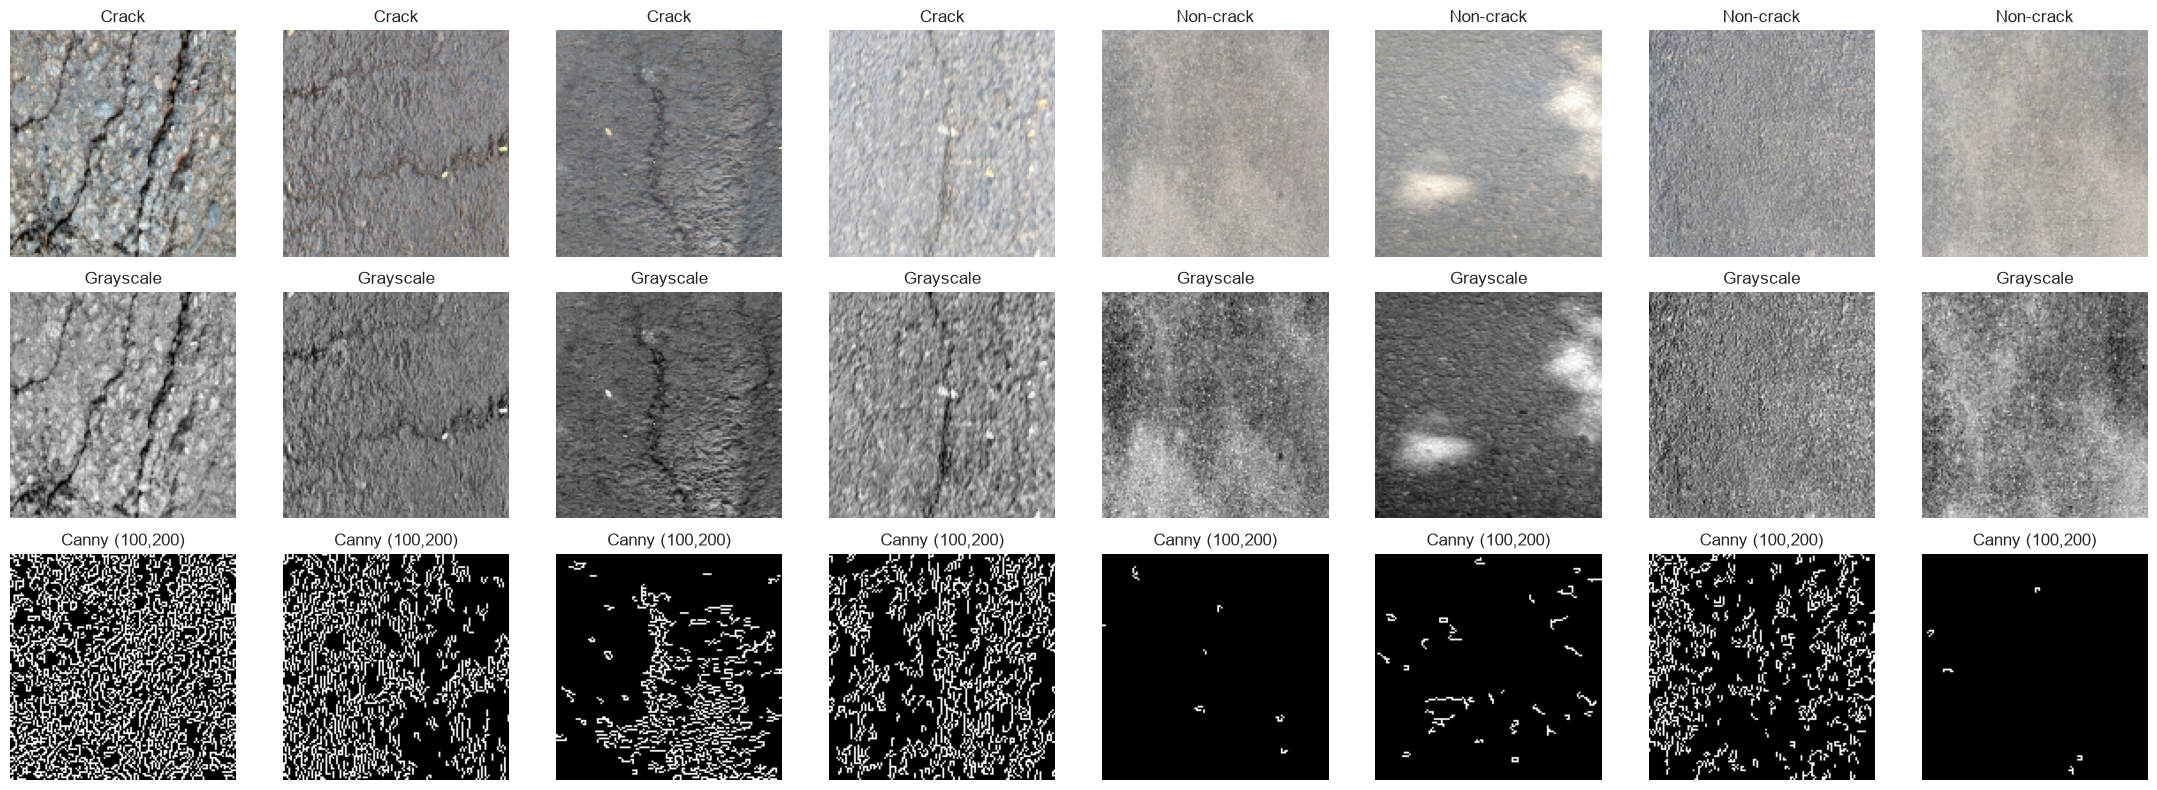

In [22]:
rng = np.random.RandomState(SEED)
crack_idx = rng.choice(np.where(labels == 1)[0], 4, replace=False)
non_idx   = rng.choice(np.where(labels == 0)[0], 4, replace=False)
rows = [("Crack", i) for i in crack_idx] + [("Non-crack", i) for i in non_idx]

fig, axes = plt.subplots(3, 8, figsize=(22, 8))
for col, (name, i) in enumerate(rows):
    axes[0, col].imshow(cv2.cvtColor(bgr_imgs[i], cv2.COLOR_BGR2RGB)); axes[0, col].set_title(name)
    axes[1, col].imshow(gray_imgs[i], cmap="gray"); axes[1, col].set_title("Grayscale")
    axes[2, col].imshow(canny_edges(gray_imgs[i]), cmap="gray"); axes[2, col].set_title("Canny (100,200)")
    for r in range(3): axes[r, col].axis("off")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/canny_samples.png", dpi=130); plt.show()

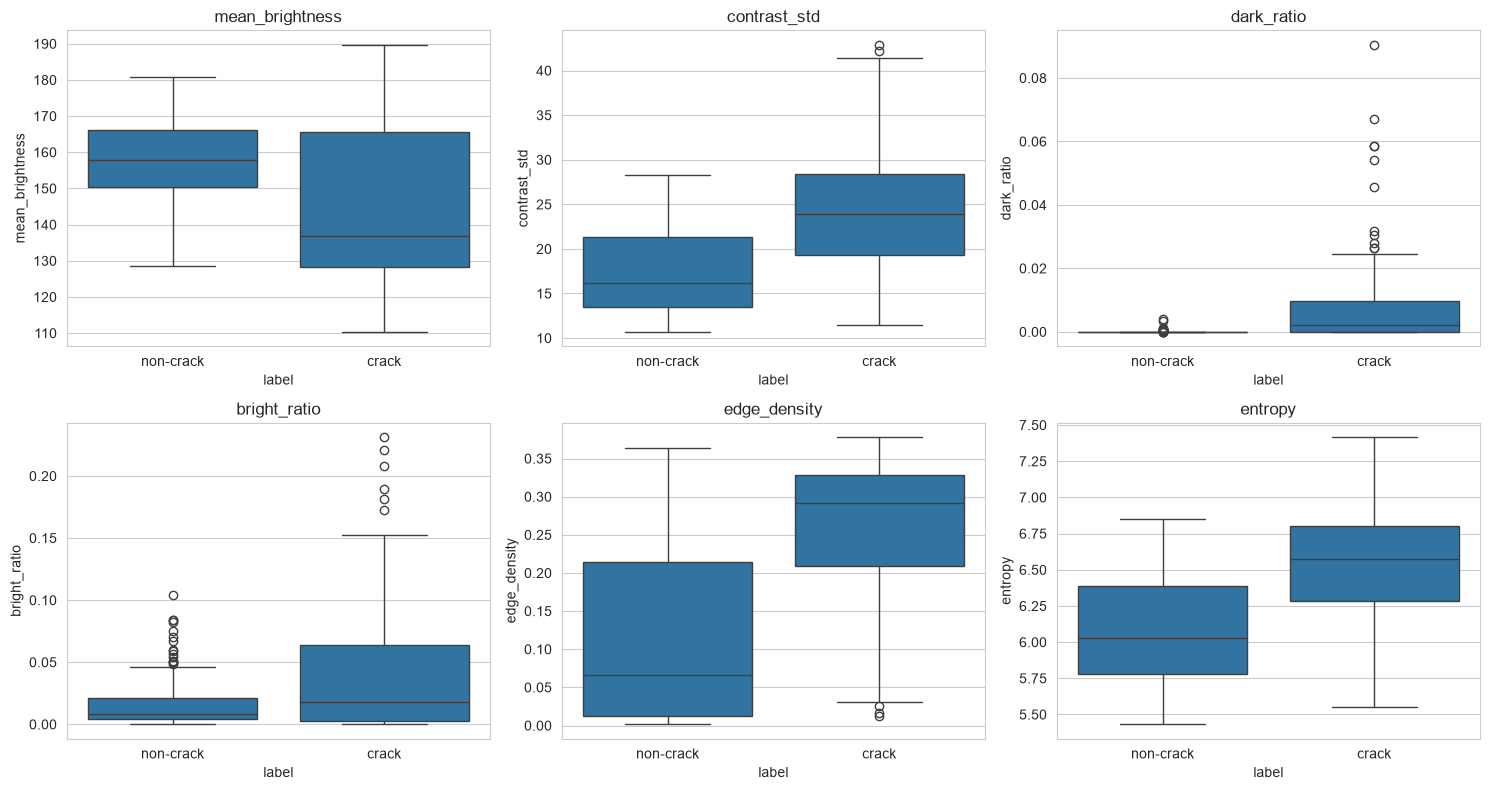

label                   0         1
mean_brightness   157.515   144.249
contrast_std       17.528    24.609
median            157.250   144.808
min                89.750    41.675
max               235.085   242.780
p5                129.366   102.838
p25               145.902   129.312
p75               168.638   160.012
p95               186.769   183.489
iqr                22.735    30.700
skewness            0.166    -0.171
kurtosis            0.537     1.016
entropy             6.097     6.562
dark_ratio          0.000     0.007
bright_ratio        0.016     0.039
edge_count       1880.875  4254.520
edge_density        0.115     0.260


In [23]:
# Which features separate the classes?
key = ["mean_brightness", "contrast_std", "dark_ratio", "bright_ratio", "edge_density", "entropy"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, f in zip(axes.ravel(), key):
    sns.boxplot(x="label", y=f, data=feat_base, ax=ax); ax.set_xticklabels(["non-crack", "crack"]); ax.set_title(f)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/feature_boxplots.png", dpi=130); plt.show()
print(feat_base.drop(columns="filename").groupby("label").mean().T.round(3))

## A6. Train classifiers and evaluate

In [24]:
def evaluate(name, model, Xtr, Xte, ytr, yte):
    t0 = time.perf_counter(); model.fit(Xtr, ytr); t_train = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = model.predict(Xte); t_pred = time.perf_counter() - t0
    res = {"model": name,
           "accuracy": accuracy_score(yte, pred),
           "precision": precision_score(yte, pred, zero_division=0),
           "recall": recall_score(yte, pred, zero_division=0),
           "f1": f1_score(yte, pred, zero_division=0),
           "train_time_s": t_train, "predict_time_s": t_pred}
    return res, confusion_matrix(yte, pred)

def image_models():
    return {
        "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
        "KNN (k=5)":           make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
        "SVM (RBF)":           make_pipeline(StandardScaler(), SVC(random_state=SEED)),
        "Decision Tree":       DecisionTreeClassifier(random_state=SEED),
        "Random Forest":       RandomForestClassifier(200, random_state=SEED),
    }

def run_image_experiment(feat_df, tag):
    X = feat_df.drop(columns=["filename", "label"]).values; y = feat_df["label"].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
    rows, cms = [], {}
    for name, m in image_models().items():
        r, cm = evaluate(name, m, Xtr, Xte, ytr, yte)
        r["cv5_accuracy"] = cross_val_score(image_models()[name], X, y, cv=skf).mean()
        r["n_features"] = X.shape[1]; r["features"] = tag
        rows.append(r); cms[name] = cm
    return pd.DataFrame(rows), cms

res_base, cms_base = run_image_experiment(feat_base, "baseline")
res_base.round(4)

,model,accuracy,precision,recall,f1,train_time_s,predict_time_s,cv5_accuracy,n_features,features
0,Logistic Regression,0.9500,0.9286,0.975,0.9512,0.0154,0.0009,0.9475,17,baseline
1,KNN (k=5),0.9500,0.9500,0.950,0.9500,0.0011,0.0099,0.9625,17,baseline
2,SVM (RBF),0.9500,0.9286,0.975,0.9512,0.0049,0.0015,0.9650,17,baseline
3,Decision Tree,0.9125,0.8837,0.950,0.9157,0.0039,0.0002,0.8875,17,baseline
4,Random Forest,0.9375,0.9268,0.950,0.9383,0.3542,0.0086,0.9525,17,baseline


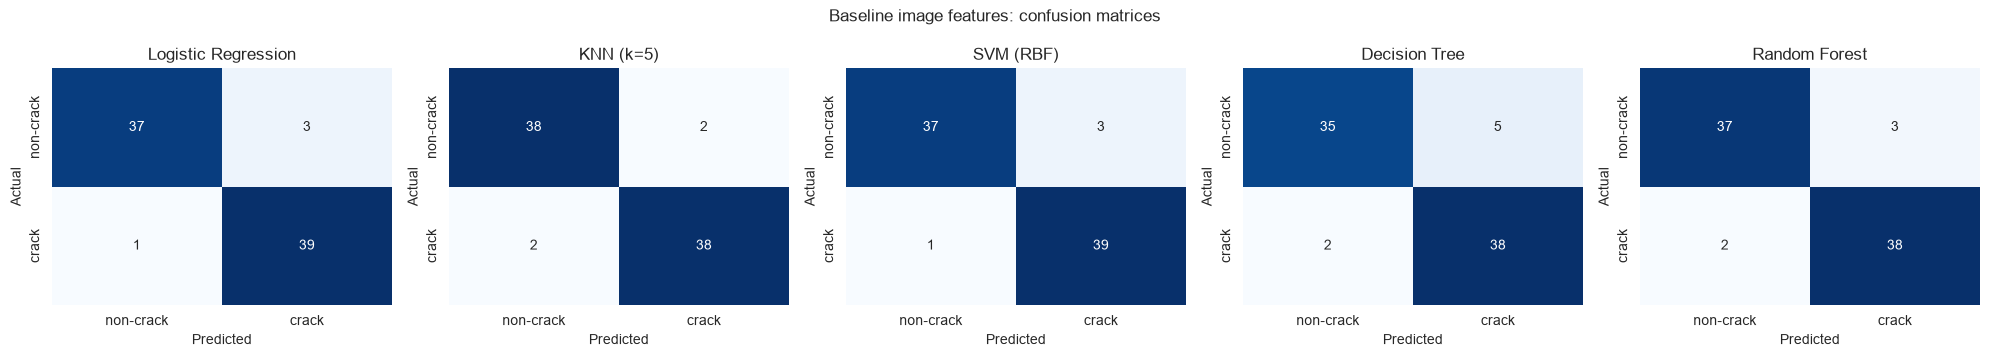

In [25]:
res_base.to_csv(f"{OUT_DIR}/image_results_baseline.csv", index=False)
def plot_cms(cms, title, fname):
    fig, axes = plt.subplots(1, len(cms), figsize=(4 * len(cms), 3.6))
    for ax, (n, cm) in zip(np.atleast_1d(axes), cms.items()):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["non-crack", "crack"], yticklabels=["non-crack", "crack"])
        ax.set_title(n); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.suptitle(title); plt.tight_layout(); plt.savefig(fname, dpi=130); plt.show()
plot_cms(cms_base, "Baseline image features: confusion matrices", f"{OUT_DIR}/confusion_matrices_image_baseline.png")

---
# Part B: Text Vectorization and Spam Classification
## B1. Load and inspect

Shape: (5172, 3002)
Columns (first 8): ['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a']

Pre-vectorized file, documents reconstructed from counts: True
Example (first 300 chars): ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm

Class distribution:
 ham (non-spam)    3672
spam              1500
Name: count, dtype: int64 
 ham (non-spam)    0.71
spam              0.29
Name: count, dtype: float64


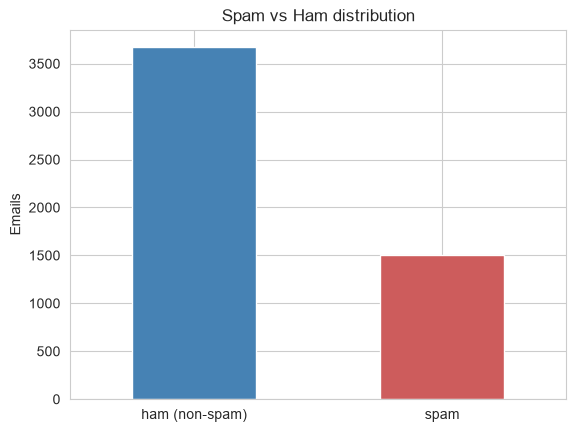

In [26]:
df_raw = pd.read_csv(TEXT_CSV)
print("Shape:", df_raw.shape); print("Columns (first 8):", list(df_raw.columns[:8]))

label_col = next(c for c in ["Prediction", "label", "Label", "v1"] if c in df_raw.columns)
y_text = df_raw[label_col]
if y_text.dtype == object:
    y_text = y_text.str.lower().map({"spam": 1, "ham": 0})
y_text = y_text.astype(int).values


text_col = next((c for c in df_raw.columns
                 if str(c).lower() in ("text", "email", "message", "body", "v2")
                 and not pd.api.types.is_numeric_dtype(df_raw[c])), None)

if text_col is not None:
    PREVECTORIZED = False
    texts = df_raw[text_col].fillna("").astype(str).tolist()
else:                                   
    PREVECTORIZED = True
    word_cols = [c for c in df_raw.columns if c not in ("Email No.", label_col)]
    words, counts = np.array(word_cols), df_raw[word_cols].values
    texts = [" ".join(np.repeat(words[np.nonzero(r)[0]], r[np.nonzero(r)[0]].astype(int))) for r in counts]

print("\nPre-vectorized file, documents reconstructed from counts:", PREVECTORIZED)
print("Example (first 300 chars):", texts[0][:300])

dist = pd.Series(y_text).map({0: "ham (non-spam)", 1: "spam"}).value_counts()
print("\nClass distribution:\n", dist, "\n", (dist / dist.sum()).round(3))
dist.plot(kind="bar", color=["steelblue", "indianred"], rot=0, title="Spam vs Ham distribution")
plt.ylabel("Emails"); plt.savefig(f"{OUT_DIR}/text_class_distribution.png", dpi=130); plt.show()


## B2. Basic text cleaning

In [27]:
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

clean = [clean_text(t) for t in texts]
Xtr_txt, Xte_txt, ytr_txt, yte_txt = train_test_split(clean, y_text, test_size=0.2, stratify=y_text, random_state=SEED)
print("Train:", len(Xtr_txt), "| Test:", len(Xte_txt))

Train: 4137 | Test: 1035


## B3-B5. CountVectorizer vs TF-IDF, with several classifiers

In [28]:
def text_models():
    return {"Multinomial NB": MultinomialNB(),
            "Logistic Regression": LogisticRegression(max_iter=2000, random_state=SEED),
            "Linear SVM": LinearSVC(random_state=SEED)}

def run_text_experiment(vec_name, vec):
    t0 = time.perf_counter(); Xtr = vec.fit_transform(Xtr_txt); t_vec = time.perf_counter() - t0
    t0 = time.perf_counter(); Xte = vec.transform(Xte_txt);     t_vec += time.perf_counter() - t0
    rows, cms = [], {}
    for name, m in text_models().items():
        r, cm = evaluate(name, m, Xtr, Xte, ytr_txt, yte_txt)   # evaluate() defined in A6
        r.update({"representation": vec_name, "n_features": Xtr.shape[1],
                  "vectorize_time_s": t_vec, "nonzero_entries": Xtr.nnz})
        rows.append(r); cms[f"{vec_name} | {name}"] = cm
    return rows, cms

rows, cms_txt = [], {}
for vname, vec in [("CountVectorizer", CountVectorizer(token_pattern=TOKEN)),
                   ("TF-IDF", TfidfVectorizer(token_pattern=TOKEN))]:
    r, c = run_text_experiment(vname, vec); rows += r; cms_txt.update(c)
res_text = pd.DataFrame(rows)[["representation", "model", "n_features", "accuracy", "precision", "recall", "f1",
                               "vectorize_time_s", "train_time_s", "predict_time_s", "nonzero_entries"]]
res_text.to_csv(f"{OUT_DIR}/text_comparison.csv", index=False)
res_text.round(4)


,representation,model,n_features,accuracy,precision,recall,f1,vectorize_time_s,train_time_s,predict_time_s,nonzero_entries
0,CountVectorizer,Multinomial NB,3000,0.9420,0.8681,0.9433,0.9042,2.0899,0.0027,0.0012,702239
1,CountVectorizer,Logistic Regression,3000,0.9826,0.9578,0.9833,0.9704,2.0899,1.2418,0.0006,702239
2,CountVectorizer,Linear SVM,3000,0.9797,0.9604,0.9700,0.9652,2.0899,1.6753,0.0018,702239
3,TF-IDF,Multinomial NB,3000,0.8802,0.9444,0.6233,0.7510,5.5709,0.0072,0.0021,702239
4,TF-IDF,Logistic Regression,3000,0.9507,0.9308,0.8967,0.9134,5.5709,0.1313,0.0009,702239
5,TF-IDF,Linear SVM,3000,0.9845,0.9641,0.9833,0.9736,5.5709,0.1380,0.0010,702239


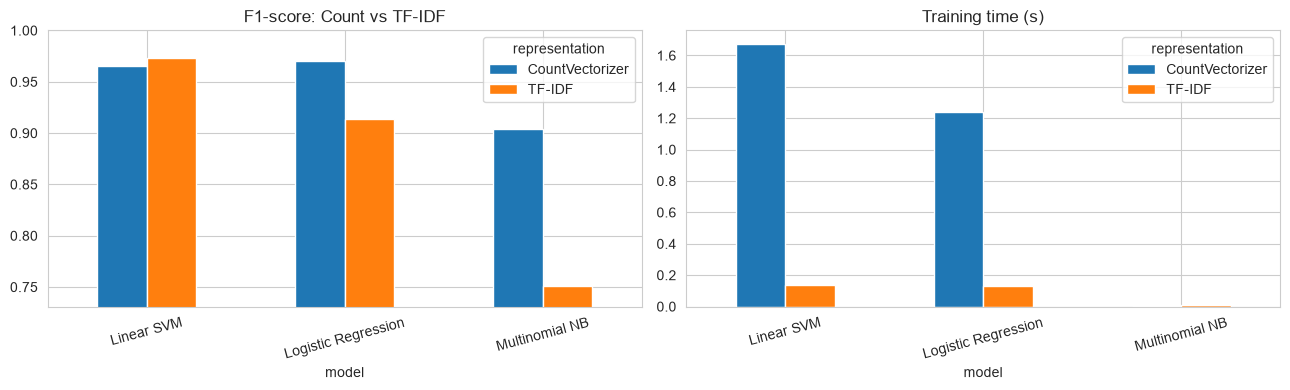

Best baseline text model: TF-IDF + Linear SVM | F1 = 0.9736


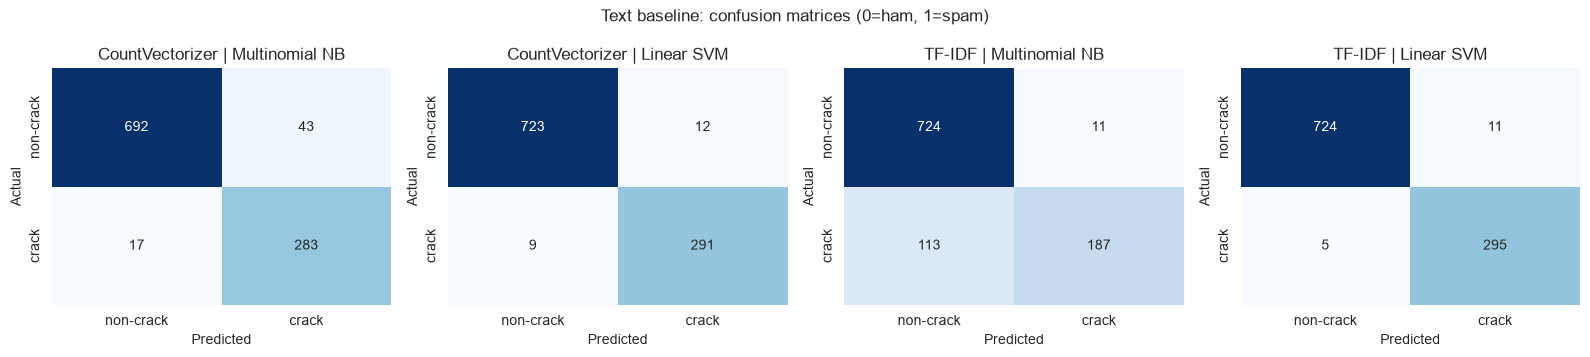

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
res_text.pivot(index="model", columns="representation", values="f1").plot(kind="bar", ax=axes[0], rot=15, ylim=(max(0, res_text.f1.min() - 0.02), 1.0))
axes[0].set_title("F1-score: Count vs TF-IDF")
res_text.pivot(index="model", columns="representation", values="train_time_s").plot(kind="bar", ax=axes[1], rot=15)
axes[1].set_title("Training time (s)"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/text_comparison.png", dpi=130); plt.show()

best = res_text.sort_values("f1", ascending=False).iloc[0]
print("Best baseline text model:", best["representation"], "+", best["model"], "| F1 =", round(best["f1"], 4))
plot_cms({k: v for k, v in cms_txt.items() if "Linear SVM" in k or "Multinomial NB" in k},
         "Text baseline: confusion matrices (0=ham, 1=spam)", f"{OUT_DIR}/confusion_matrices_text_baseline.png")

---
# Part C: Improve the Representation


In [30]:
def grid_edge_stats(edges, n=4):
    h, w = edges.shape; bh, bw = h // n, w // n
    d = np.array([(edges[i*bh:(i+1)*bh, j*bw:(j+1)*bw] > 0).mean() for i in range(n) for j in range(n)])
    return d.max(), d.std()

def improved_row(gray):
    row = intensity_features(gray)
    e = canny_edges(gray, blur=True, auto=True)
    gmax, gstd = grid_edge_stats(e)
    row.update({"edge_count": int((e > 0).sum()), "edge_density": (e > 0).mean(),
                "grid_edge_max": gmax, "grid_edge_std": gstd,
                "laplacian_var": cv2.Laplacian(gray, cv2.CV_64F).var()})
    return row

t0 = time.perf_counter(); feat_imp = pd.DataFrame([improved_row(g) for g in gray_imgs]); t_imp = time.perf_counter() - t0
t0 = time.perf_counter(); _ = pd.DataFrame([baseline_row(g) for g in gray_imgs]); t_base = time.perf_counter() - t0
feat_imp.insert(0, "filename", feat_base["filename"]); feat_imp["label"] = labels
feat_imp.to_csv(f"{OUT_DIR}/image_features_improved.csv", index=False)
print(f"Feature extraction time: baseline {t_base:.2f}s | improved {t_imp:.2f}s")

res_imp, cms_imp = run_image_experiment(feat_imp, "improved")
cmp_img = pd.concat([res_base, res_imp])
cmp_img.to_csv(f"{OUT_DIR}/image_improvement_comparison.csv", index=False)
cmp_img.pivot(index="model", columns="features", values=["accuracy", "recall", "f1", "cv5_accuracy"]).round(4)

Feature extraction time: baseline 3.53s | improved 4.67s


accuracy            recall                f1           \
features            baseline improved baseline improved baseline improved   
model                                                                       
Decision Tree         0.9125   0.8625    0.950    0.875   0.9157   0.8642   
KNN (k=5)             0.9500   0.9500    0.950    0.950   0.9500   0.9500   
Logistic Regression   0.9500   0.9125    0.975    0.900   0.9512   0.9114   
Random Forest         0.9375   0.9375    0.950    0.950   0.9383   0.9383   
SVM (RBF)             0.9500   0.9500    0.975    0.975   0.9512   0.9512   

                    cv5_accuracy           
features                baseline improved  
model                                      
Decision Tree             0.8875   0.9325  
KNN (k=5)                 0.9625   0.9600  
Logistic Regression       0.9475   0.9500  
Random Forest             0.9525   0.9525  
SVM (RBF)                 0.9650   0.9650

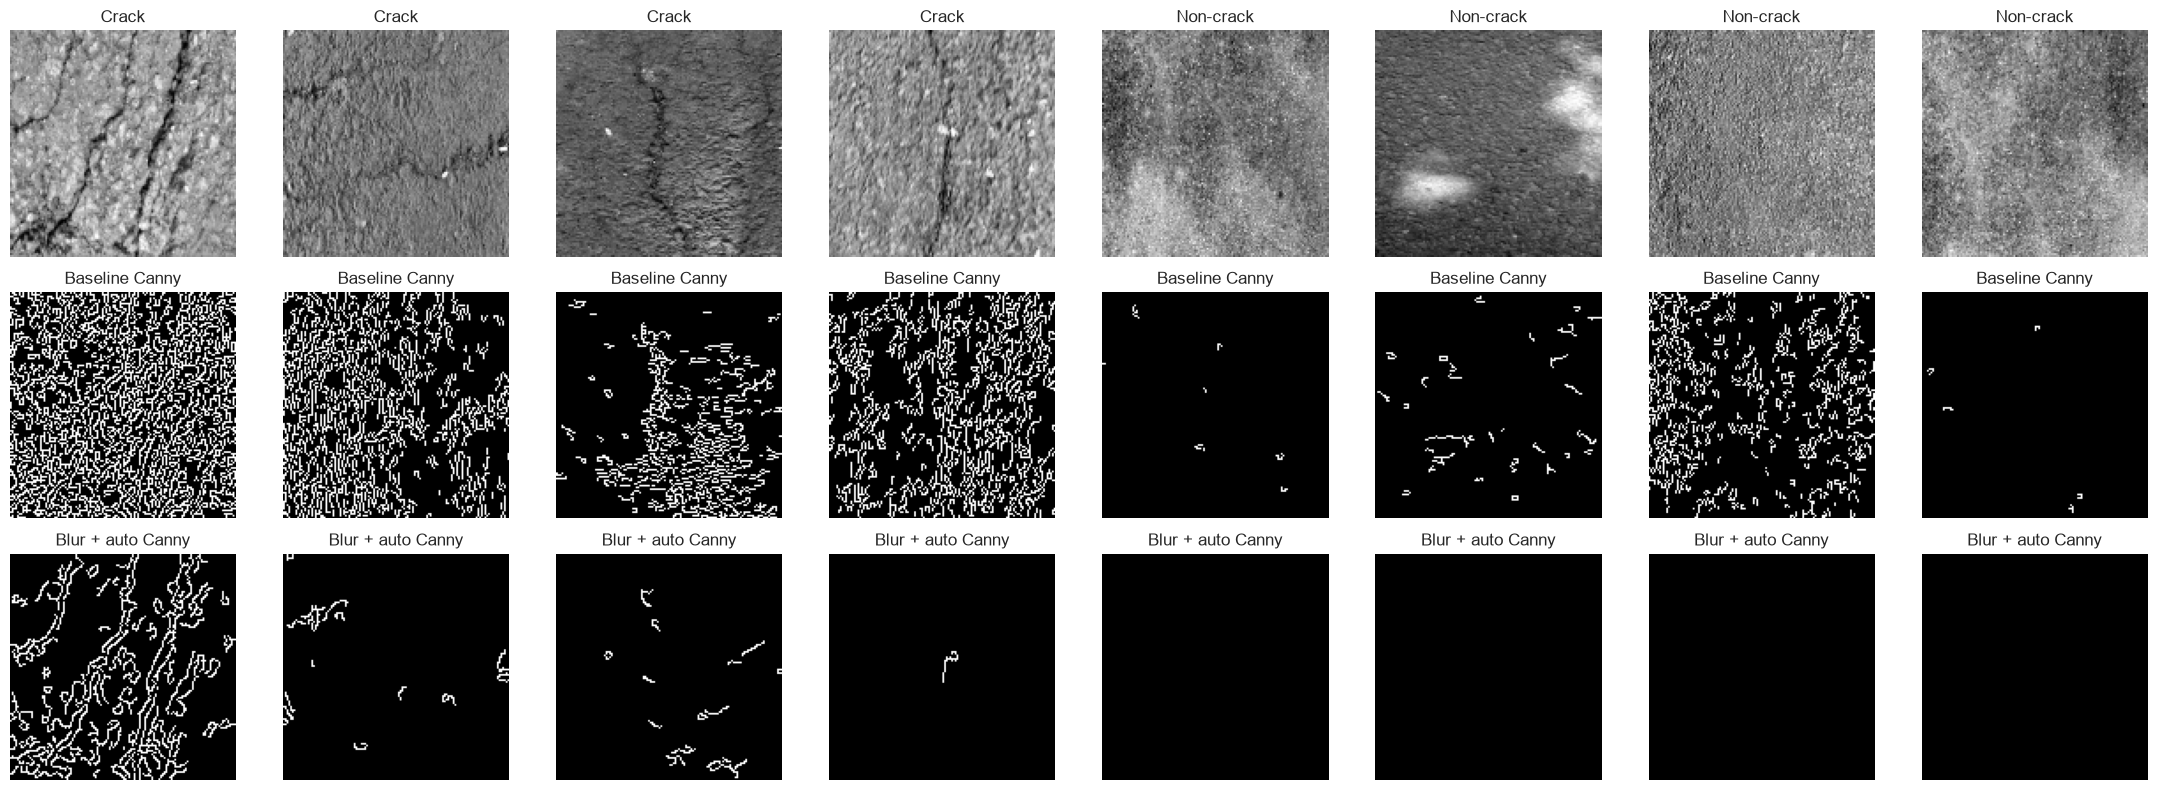

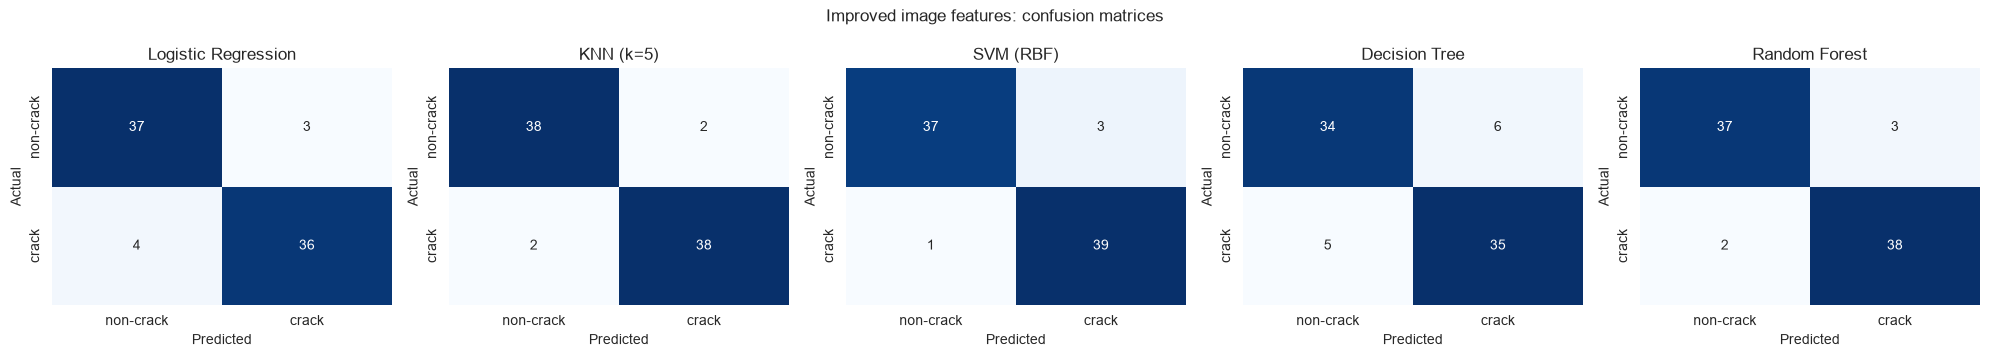

In [31]:
# Visual check: does blur + auto thresholds reduce texture edges?
fig, axes = plt.subplots(3, 8, figsize=(22, 8))
for col, (name, i) in enumerate([("Crack", i) for i in crack_idx] + [("Non-crack", i) for i in non_idx]):
    axes[0, col].imshow(gray_imgs[i], cmap="gray"); axes[0, col].set_title(name)
    axes[1, col].imshow(canny_edges(gray_imgs[i]), cmap="gray"); axes[1, col].set_title("Baseline Canny")
    axes[2, col].imshow(canny_edges(gray_imgs[i], blur=True, auto=True), cmap="gray"); axes[2, col].set_title("Blur + auto Canny")
    for r in range(3): axes[r, col].axis("off")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/canny_baseline_vs_improved.png", dpi=130); plt.show()
plot_cms(cms_imp, "Improved image features: confusion matrices", f"{OUT_DIR}/confusion_matrices_image_improved.png")

## C2. Text improvement


In [32]:
variants = {
    "Baseline (all words)":          dict(),
    "max_features=1000":             dict(max_features=1000),
    "max_features=500":              dict(max_features=500),
    "stop_words='english'":          dict(stop_words="english"),
    "min_df=5, max_df=0.9":          dict(min_df=5, max_df=0.9),
    "stop + max_features=1000":      dict(stop_words="english", max_features=1000),
}
if not PREVECTORIZED:
    variants["bigrams (1,2), max_f=5000"] = dict(ngram_range=(1, 2), max_features=5000, min_df=2)

rows = []
for vname, kw in variants.items():
    r, _ = run_text_experiment(vname, TfidfVectorizer(token_pattern=TOKEN, **kw)); rows += r
cmp_txt = pd.DataFrame(rows)[["representation", "model", "n_features", "accuracy", "precision", "recall", "f1",
                              "vectorize_time_s", "train_time_s", "predict_time_s"]]
cmp_txt.to_csv(f"{OUT_DIR}/text_improvement_comparison.csv", index=False)
cmp_txt.round(4)


,representation,model,n_features,accuracy,precision,recall,f1,vectorize_time_s,train_time_s,predict_time_s
0,Baseline (all words),Multinomial NB,3000,0.8802,0.9444,0.6233,0.7510,4.9366,0.0070,0.0023
1,Baseline (all words),Logistic Regression,3000,0.9507,0.9308,0.8967,0.9134,4.9366,0.1266,0.0010
2,Baseline (all words),Linear SVM,3000,0.9845,0.9641,0.9833,0.9736,4.9366,0.1311,0.0013
3,max_features=1000,Multinomial NB,1000,0.9188,0.9320,0.7767,0.8473,4.8685,0.0142,0.0023
4,max_features=1000,Logistic Regression,1000,0.9420,0.9196,0.8767,0.8976,4.8685,0.1606,0.0015
5,max_features=1000,Linear SVM,1000,0.9797,0.9486,0.9833,0.9656,4.8685,0.1008,0.0009
6,max_features=500,Multinomial NB,500,0.8483,0.9333,0.5133,0.6624,4.7852,0.0069,0.0016
7,max_features=500,Logistic Regression,500,0.9333,0.9024,0.8633,0.8825,4.7852,0.0945,0.0009
8,max_features=500,Linear SVM,500,0.9700,0.9243,0.9767,0.9498,4.7852,0.0872,0.0008
9,stop_words='english',Multinomial NB,2762,0.8966,0.9488,0.6800,0.7922,4.7988,0.0064,0.0013


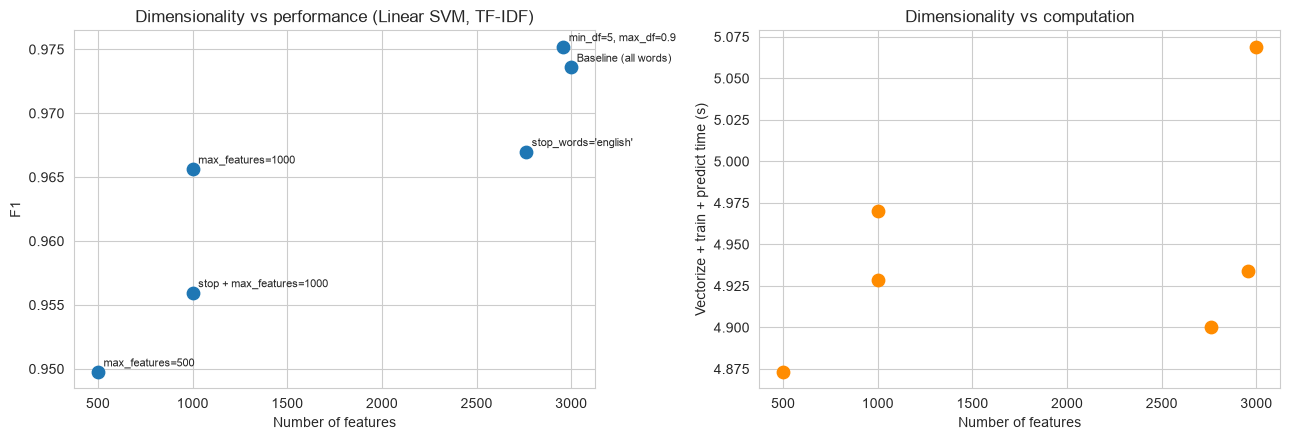

In [33]:
sub = cmp_txt[cmp_txt.model == "Linear SVM"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(sub.n_features, sub.f1, s=80)
for _, r in sub.iterrows(): ax[0].annotate(r.representation, (r.n_features, r.f1), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[0].set_xlabel("Number of features"); ax[0].set_ylabel("F1"); ax[0].set_title("Dimensionality vs performance (Linear SVM, TF-IDF)")
ax[1].scatter(sub.n_features, sub.vectorize_time_s + sub.train_time_s + sub.predict_time_s, s=80, color="darkorange")
ax[1].set_xlabel("Number of features"); ax[1].set_ylabel("Vectorize + train + predict time (s)"); ax[1].set_title("Dimensionality vs computation")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/text_tradeoff.png", dpi=130); plt.show()

## C3. dimensionality vs computation vs performance


In [34]:
print("IMAGE (best model per feature set)")
print(cmp_img.sort_values("f1", ascending=False).groupby("features").head(1)
      [["features", "model", "n_features", "accuracy", "recall", "f1", "cv5_accuracy", "train_time_s"]].round(4).to_string(index=False))
print("\nTEXT (Linear SVM per representation)")
print(cmp_txt[cmp_txt.model == "Linear SVM"]
      [["representation", "n_features", "accuracy", "f1", "vectorize_time_s", "train_time_s", "predict_time_s"]].round(4).to_string(index=False))


IMAGE (best model per feature set)
features               model  n_features  accuracy  recall     f1  cv5_accuracy  train_time_s
baseline Logistic Regression          17      0.95   0.975 0.9512        0.9475        0.0154
improved           SVM (RBF)          20      0.95   0.975 0.9512        0.9650        0.0070

TEXT (Linear SVM per representation)
          representation  n_features  accuracy     f1  vectorize_time_s  train_time_s  predict_time_s
    Baseline (all words)        3000    0.9845 0.9736            4.9366        0.1311          0.0013
       max_features=1000        1000    0.9797 0.9656            4.8685        0.1008          0.0009
        max_features=500         500    0.9700 0.9498            4.7852        0.0872          0.0008
    stop_words='english'        2762    0.9807 0.9670            4.7988        0.1005          0.0010
    min_df=5, max_df=0.9        2958    0.9855 0.9752            4.8455        0.0875          0.0012
stop + max_features=1000        1